# Raincloud Plot

A raincloud plot shows a distribution three ways at once: the **cloud** (a half violin) gives its shape, the **rain** (one point per observation) shows every value, and the **box** sums it up with the median and quartiles. The reader gets all three without the author having to choose one. This guide shows how to create raincloud plots with the [datachart.charts.RaincloudPlot](../../../references/charts/raincloudplot/#datachart.charts.RaincloudPlot) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-raincloud-plot), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import RaincloudPlot

## Basics

The examples in this guide share one dataset: the body mass of the 342 penguins with a recorded mass in the [Palmer penguins](https://allisonhorst.github.io/palmerpenguins/) dataset (CC0), three species measured on the islands of the Palmer Archipelago in Antarctica. The data lives in a hidden cell. `chart_data` holds the body mass (in g) of every penguin, labeled with its species; `flipper_data` holds the flipper length (in mm) the same way; `PENGUINS` keeps the sex of every penguin, which the later sections reuse. The data has a story a single summary would hide: Gentoo penguins are far heavier than the other two species, and within each species the males are heavier than the females, so each distribution is really two.

In [2]:
# the 342 Palmer penguins with a recorded body mass, grouped by species and sex
PENGUINS = [
    {
        "species": "Adelie",
        "sex": "Female",
        "body_mass": [
            3800, 3250, 3450, 3625, 3200, 3700, 3450, 3325, 3400, 3800, 3800, 3200, 3150,
            3250, 3300, 3325, 3550, 3300, 3150, 3100, 3000, 3450, 3500, 3450, 2900, 3550,
            2850, 3150, 3600, 2850, 3350, 3050, 3600, 3550, 3700, 3700, 3550, 3200, 3800,
            3350, 3500, 3600, 3550, 3400, 3300, 3700, 2900, 3725, 3075, 2925, 3750, 3175,
            3825, 3200, 3900, 2900, 3350, 3150, 3450, 3050, 3275, 3050, 3325, 3500, 3425,
            3175, 3400, 3400, 3050, 3000, 3475, 3450, 3700,
        ],
        "flipper_length": [
            186, 195, 193, 181, 182, 185, 195, 184, 174, 189, 187, 187, 172, 178, 188, 195,
            180, 181, 182, 186, 185, 190, 186, 190, 187, 186, 181, 185, 185, 184, 195, 190,
            190, 196, 190, 191, 187, 189, 187, 191, 189, 190, 202, 185, 187, 190, 178, 192,
            183, 193, 199, 181, 198, 193, 191, 188, 189, 187, 176, 186, 191, 191, 190, 193,
            187, 191, 185, 193, 188, 192, 184, 195, 187,
        ],
    },
    {
        "species": "Adelie",
        "sex": "Male",
        "body_mass": [
            3750, 3650, 4675, 3800, 4400, 4500, 4200, 3600, 3950, 3800, 3550, 3950, 3900,
            3900, 4150, 3950, 4650, 3900, 4400, 4600, 3425, 4150, 4300, 4050, 3700, 3800,
            3750, 4400, 4050, 3950, 4100, 4450, 3900, 4150, 4250, 3900, 4000, 4700, 4200,
            3550, 3800, 3950, 4300, 4450, 4300, 4350, 4100, 4725, 4250, 3550, 3900, 4775,
            4600, 4275, 4075, 3775, 3325, 3500, 3875, 4000, 4300, 4000, 3500, 4475, 3900,
            3975, 4250, 3475, 3725, 3650, 4250, 3750, 4000,
        ],
        "flipper_length": [
            181, 190, 195, 191, 198, 197, 194, 180, 185, 180, 183, 180, 178, 184, 196, 190,
            184, 195, 196, 190, 182, 191, 188, 200, 191, 193, 194, 195, 192, 192, 188, 198,
            190, 197, 195, 184, 195, 196, 193, 194, 190, 189, 205, 186, 208, 196, 192, 203,
            190, 184, 190, 197, 191, 197, 196, 199, 189, 198, 202, 199, 195, 210, 197, 199,
            190, 200, 193, 187, 190, 185, 190, 193, 201,
        ],
    },
    {
        "species": "Adelie",
        "sex": None,
        "body_mass": [
            3475, 4250, 3300, 3700, 2975,
        ],
        "flipper_length": [
            193, 190, 186, 180, 179,
        ],
    },
    {
        "species": "Chinstrap",
        "sex": "Female",
        "body_mass": [
            3500, 3525, 3950, 3250, 4150, 3800, 3700, 3575, 3700, 3450, 3600, 2900, 3300,
            3400, 3700, 3200, 3350, 3900, 3850, 2700, 3650, 3500, 3675, 3400, 3675, 3325,
            3600, 3350, 3250, 3525, 3650, 3650, 3400, 3775,
        ],
        "flipper_length": [
            192, 188, 198, 178, 195, 193, 185, 190, 181, 190, 181, 187, 195, 200, 191, 187,
            187, 199, 195, 192, 187, 196, 196, 190, 198, 199, 193, 187, 191, 194, 189, 195,
            202, 198,
        ],
    },
    {
        "species": "Chinstrap",
        "sex": "Male",
        "body_mass": [
            3900, 3650, 3725, 3750, 3700, 3775, 4050, 4050, 3300, 4400, 3400, 3800, 4150,
            3800, 4550, 4300, 4100, 3600, 4800, 4500, 3950, 3550, 4450, 4300, 3250, 3950,
            4050, 3450, 4050, 3800, 3950, 4000, 3775, 4100,
        ],
        "flipper_length": [
            196, 193, 197, 197, 198, 194, 201, 201, 197, 195, 191, 193, 197, 200, 205, 201,
            203, 195, 210, 205, 210, 196, 201, 212, 187, 201, 203, 197, 203, 202, 206, 207,
            193, 210,
        ],
    },
    {
        "species": "Gentoo",
        "sex": "Female",
        "body_mass": [
            4500, 4450, 4550, 4800, 4400, 4650, 4650, 4200, 4150, 4800, 5000, 4400, 5000,
            4600, 4700, 5050, 5150, 4950, 4350, 3950, 4300, 4900, 4200, 5100, 4850, 4400,
            4900, 4300, 4450, 4200, 4400, 4700, 4700, 4750, 5200, 4700, 4600, 4750, 4625,
            4725, 4750, 4600, 4875, 4950, 4750, 4850, 4875, 4625, 4850, 4975, 4700, 4575,
            5000, 4650, 4375, 4925, 4850, 5200,
        ],
        "flipper_length": [
            211, 210, 210, 211, 209, 214, 214, 210, 210, 209, 215, 213, 215, 210, 209, 207,
            220, 213, 208, 208, 210, 217, 210, 213, 210, 210, 217, 208, 208, 208, 214, 219,
            220, 216, 217, 216, 209, 215, 212, 212, 212, 218, 212, 218, 212, 214, 222, 203,
            219, 215, 210, 208, 216, 213, 217, 214, 215, 212,
        ],
    },
    {
        "species": "Gentoo",
        "sex": "Male",
        "body_mass": [
            5700, 5700, 5400, 5200, 5150, 5550, 5850, 5850, 6300, 5350, 5700, 5050, 5100,
            5650, 5550, 5250, 6050, 5400, 5250, 5350, 5700, 4750, 5550, 5400, 5300, 5300,
            5000, 5050, 5000, 5550, 5300, 5650, 5700, 5800, 5550, 5000, 5100, 5800, 6000,
            5950, 5450, 5350, 5600, 5300, 5550, 5400, 5650, 5200, 4925, 5250, 5600, 5500,
            5500, 5500, 5500, 5950, 5500, 5850, 6000, 5750, 5400,
        ],
        "flipper_length": [
            230, 218, 215, 219, 215, 216, 213, 217, 221, 222, 218, 215, 215, 215, 220, 222,
            230, 220, 219, 208, 225, 216, 222, 225, 215, 220, 225, 220, 220, 224, 221, 231,
            230, 229, 223, 221, 221, 230, 220, 223, 221, 224, 228, 218, 230, 228, 224, 226,
            216, 225, 228, 228, 215, 219, 209, 229, 230, 230, 222, 222, 213,
        ],
    },
    {
        "species": "Gentoo",
        "sex": None,
        "body_mass": [
            4100, 4650, 4725, 4875,
        ],
        "flipper_length": [
            216, 214, 216, 217,
        ],
    },
]

chart_data = [
    {"label": penguin["species"], "value": mass}
    for penguin in PENGUINS
    for mass in penguin["body_mass"]
]
flipper_data = [
    {"label": penguin["species"], "value": length}
    for penguin in PENGUINS
    for length in penguin["flipper_length"]
]

SPECIES = ["Adelie", "Chinstrap", "Gentoo"]

Each data point is a dictionary with a `label` (the group) and a `value`. The points that share a `label` form one raincloud, so three species give three rainclouds:

In [3]:
chart_data[:3]

[{'label': 'Adelie', 'value': 3800},
 {'label': 'Adelie', 'value': 3250},
 {'label': 'Adelie', 'value': 3450}]

**Basic example.** Only the `data` argument is required. Each group draws its three parts side by side at one category position: the rain on the left, packed outward so no two penguins overlap, the box next to it, and the cloud on the right. The groups follow the order in which their labels first appear in the data (there is no sorting parameter, so reorder the data to reorder the groups), and each group takes one palette color for all three parts.

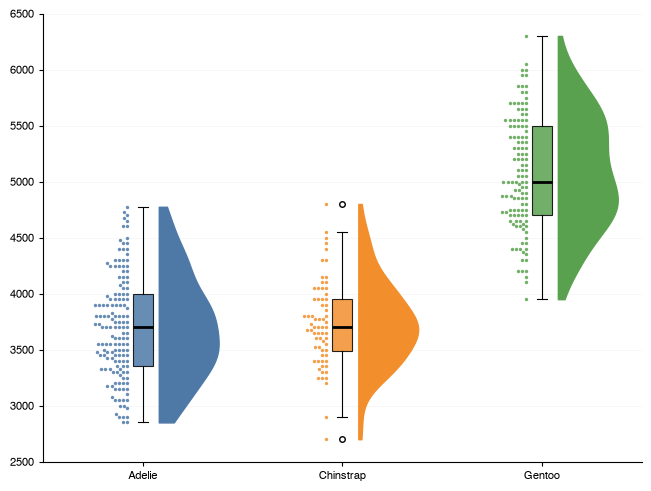

In [4]:
RaincloudPlot(
    # add the data to the chart
    data=chart_data
).show()

## Customizing the Raincloud Plot

Every customization is either a keyword argument of `RaincloudPlot` or an attribute of its `style` dictionary: the `plot_violin_*` attributes style the cloud, the `plot_swarm_*` attributes the rain, and the `plot_box_*` attributes the box. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                                             | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| fix the axis range or format the ticks      | `ymin`, `ymax`, `yticks`, `yticks_format`                               | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| resize the figure                           | `figsize`                                                               | [Figure size and grid](#figure-size-and-grid) |
| show grid lines                             | `show_grid`                                                             | [Figure size and grid](#figure-size-and-grid) |
| change the cloud, rain, or box style        | `style={"plot_violin_alpha": ..., "plot_swarm_size": ..., "plot_box_linewidth": ...}` | [Cloud, rain and box style](#cloud-rain-and-box-style) |
| smooth or sharpen the cloud                 | `bandwidth`                                                             | [Cloud bandwidth](#cloud-bandwidth) |
| jitter the rain instead of packing it       | `mode`, `jitter`                                                        | [Rain modes](#rain-modes) |
| hide the box outliers                       | `show_outliers`                                                         | [Box outliers](#box-outliers) |
| print each group's median, min and max      | `show_values`, `value_format`                                           | [Value labels](#value-labels) |
| draw the rainclouds horizontally            | `orientation`                                                           | [Horizontal rainclouds](#horizontal-rainclouds) |
| highlight some groups, mute the rest        | `emphasis`, `emphasis_rule`                                             | [Emphasis](#emphasis) |
| mark a threshold or shade a range           | `hlines`, `dlines`, `vlines`, `hspans`, `vspans`                      | [Reference lines and bands](#reference-lines-and-bands) |
| put a note on the chart                     | `texts`                                                                 | [Text annotations](#text-annotations) |
| use dates as group labels                   | `date` objects as `label`, `xticks_format`                              | [Date labels](#date-labels) |
| list the groups in a titled legend          | `show_legend`, `legend`                                                 | [Legend](#legend) |
| draw several datasets side by side          | `data` as a list of lists, `subtitle`, `sharey`, `max_cols`             | [Multiple Raincloud Plots](#multiple-raincloud-plots) |
| overlay or arrange the raincloud with other charts | `Panel`, `Grid`                                                  | [Composing with Panel and Grid](#composing-with-panel-and-grid) |
| use a logarithmic value axis                | `scaley`                                                                | [Logarithmic scale](#logarithmic-scale) |
| plot data with other key names              | `label`, `value`                                                        | [Custom data keys](#custom-data-keys) |
| save the chart to a file                    | `save_figure`                                                           | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `mode` | [`SWARM_MODE`](../../../references/constants/#datachart.constants.SWARM_MODE) |
| `bandwidth` | [`BANDWIDTH`](../../../references/constants/#datachart.constants.BANDWIDTH) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |
| `orientation` | [`ORIENTATION`](../../../references/constants/#datachart.constants.ORIENTATION) |
| `scaley` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |
| `xticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `yticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |

The full list of style attributes is in the [datachart.typings.RaincloudStyleAttrs](../../../references/charts/raincloudplot/#datachart.typings.RaincloudStyleAttrs) type; the full list of parameters is in the [datachart.charts.RaincloudPlot](../../../references/charts/raincloudplot/#datachart.charts.RaincloudPlot) reference.

### Title, axis labels and ticks

Without a title and axis labels the reader cannot tell what the rainclouds measure or in which unit; `title`, `xlabel` and `ylabel` say it. `ymin` and `ymax` fix the value axis, which matters when several charts must be read against each other, and `yticks` with `yticks_format` place and format the ticks: a thousands separator makes gram values easier to read.

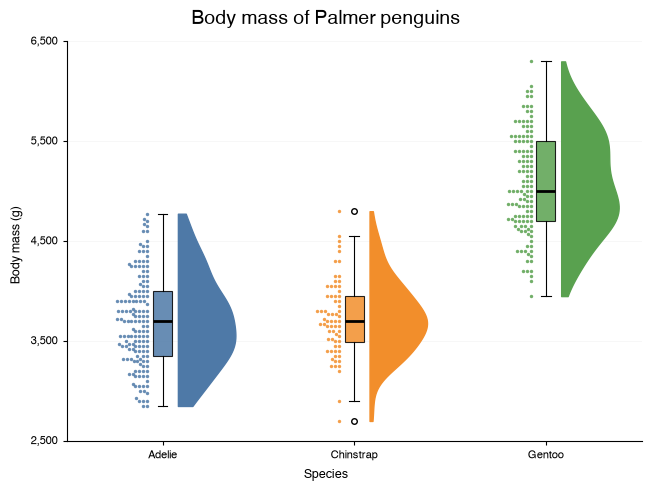

In [5]:
RaincloudPlot(
    data=chart_data,
    # add the title
    title="Body mass of Palmer penguins",
    # add the x and y axis labels
    xlabel="Species",
    ylabel="Body mass (g)",
    # fix the value axis and format its ticks
    ymin=2500,
    ymax=6500,
    yticks=[2500, 3500, 4500, 5500, 6500],
    yticks_format="{x:,.0f}",
).show()

### Figure size and grid

A few groups side by side read best in a wide, short figure. `figsize` takes a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE), sized for a full or half page width. Grid lines let the eye carry a median across to the axis; `show_grid` draws them with a [SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) member, and `SHOW_GRID.Y` keeps them on the value axis, where they help. `aspect_ratio` ([ASPECT_RATIO](../../../references/constants/#datachart.constants.ASPECT_RATIO)) fixes the ratio of the axes; a raincloud rarely needs it.

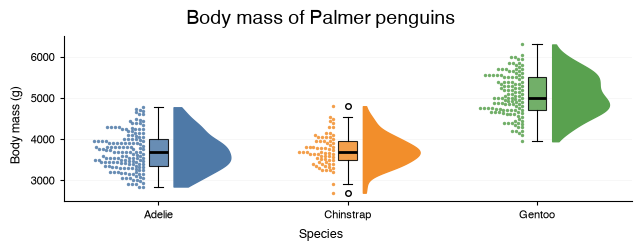

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

RaincloudPlot(
    data=chart_data,
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    # a wide, short figure
    figsize=FIG_SIZE.FULL_SHORT,
    # grid lines along the value axis only
    show_grid=SHOW_GRID.Y,
).show()

### Cloud, rain and box style

Three parts in one color can compete for attention. The `style` dictionary tunes each part: the `plot_violin_*` attributes the cloud ([ViolinStyleAttrs](../../../references/charts/violinplot/#datachart.typings.ViolinStyleAttrs)), the `plot_swarm_*` attributes the rain ([SwarmStyleAttrs](../../../references/charts/swarmplot/#datachart.typings.SwarmStyleAttrs)), and the `plot_box_*` attributes the box ([BoxStyleAttrs](../../../references/charts/boxplot/#datachart.typings.BoxStyleAttrs)); any attribute left out keeps the value of the active theme. A lighter cloud, smaller and fainter rain, and a bolder box put the summary in front and leave the shape and the raw values as context. The box takes the group color as its fill and the theme's font color for its edges, median, whiskers and caps.

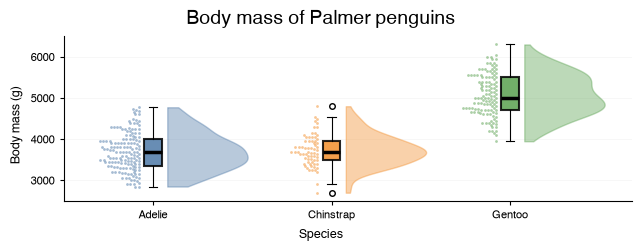

In [7]:
RaincloudPlot(
    data=chart_data,
    style={
        # a lighter, wider cloud
        "plot_violin_alpha": 0.4,
        "plot_violin_width": 0.9,
        # smaller, fainter rain
        "plot_swarm_size": 4,
        "plot_swarm_alpha": 0.5,
        # a bolder box
        "plot_box_linewidth": 1.5,
        "plot_box_median_linewidth": 2.5,
    },
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Cloud bandwidth

The cloud is a kernel density estimate, and its smoothing decides what shape the reader sees: too smooth, and a distribution with two peaks looks like one. `bandwidth` takes a rule from [BANDWIDTH](../../../references/constants/#datachart.constants.BANDWIDTH) (`BANDWIDTH.SCOTT`, the default, or `BANDWIDTH.SILVERMAN`) or a scalar factor, where smaller values follow the data more closely. Each species mixes lighter females and heavier males, and a narrow bandwidth shows it: the Gentoo cloud splits into two humps.

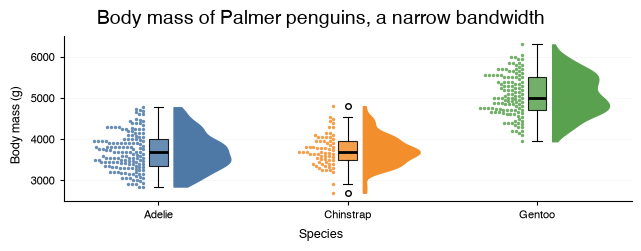

In [8]:
RaincloudPlot(
    data=chart_data,
    # a narrow bandwidth follows the data closely
    bandwidth=0.3,
    title="Body mass of Palmer penguins, a narrow bandwidth",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Rain modes

A swarm packs the rain so no two points overlap, which is exact but costs width and time as the groups grow. `mode` chooses how the rain spreads, with a [SWARM_MODE](../../../references/constants/#datachart.constants.SWARM_MODE) member: `SWARM_MODE.SWARM` (the default) packs the points outward from the box, `SWARM_MODE.STRIP` scatters them at random across the rain's width. `jitter` sets the width of that band as a fraction of the category width (0.4, the default, fills the rain's cell); the jitter is seeded, so the same data draws the same chart. The strip mode suits many thousands of points, where a swarm would fill its whole width anyway.

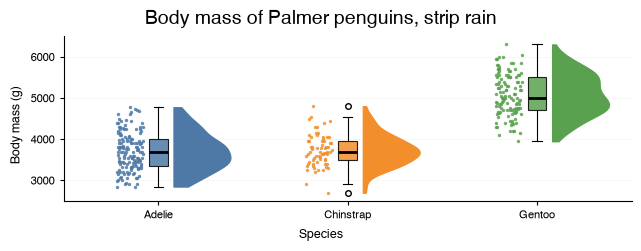

In [9]:
from datachart.constants import SWARM_MODE

RaincloudPlot(
    data=chart_data,
    # scatter the rain instead of packing it
    mode=SWARM_MODE.STRIP,
    # in a band half as wide as the rain's cell
    jitter=0.2,
    title="Body mass of Palmer penguins, strip rain",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Box outliers

The box marks the values beyond 1.5 times the interquartile range as outliers, but in a raincloud those penguins are already in the rain, so the markers repeat them (the two Chinstrap circles above). `show_outliers=False` hides them and keeps the box a plain summary.

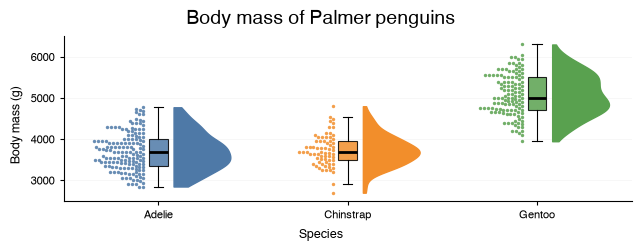

In [10]:
RaincloudPlot(
    data=chart_data,
    # the rain already shows every value
    show_outliers=False,
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Value labels

When the numbers matter, `show_values` prints each group's median beside its box, and its minimum and maximum beside the rain points holding them; the cloud carries no labels. `value_format` formats them with a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) member or any `"{x:.1f}"` style string, and the `plot_value_*` style attributes ([ValueLabelStyleAttrs](../../../references/typings/#datachart.typings.ValueLabelStyleAttrs)) set their font. The labels show that the heaviest Adelie and Chinstrap penguins weigh about as much as a typical Gentoo.

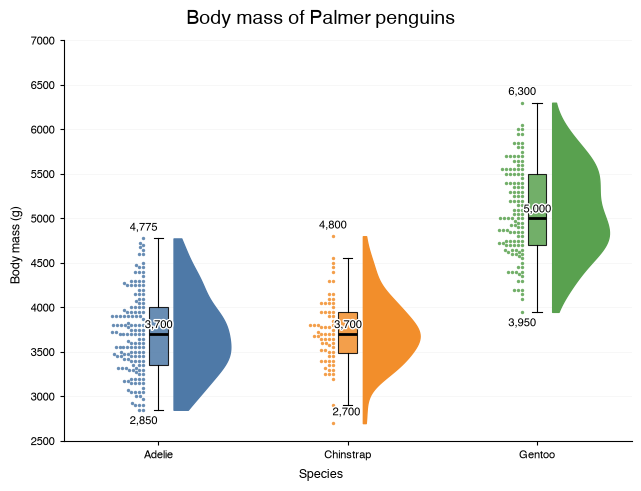

In [11]:
from datachart.constants import VALUE_FORMAT

RaincloudPlot(
    data=chart_data,
    # print the median, min and max of every group
    show_values=True,
    value_format=VALUE_FORMAT.THOUSANDS,
    style={"plot_value_fontsize": 8},
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    show_outliers=False,
).show()

### Horizontal rainclouds

Long group names and a value axis that reads left to right both call for horizontal rainclouds. `orientation=ORIENTATION.HORIZONTAL` ([ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION)) puts the groups on the y-axis, with the cloud above and the box and rain below it; the axis labels and the grid swap with the orientation, and the first group sits at the bottom.

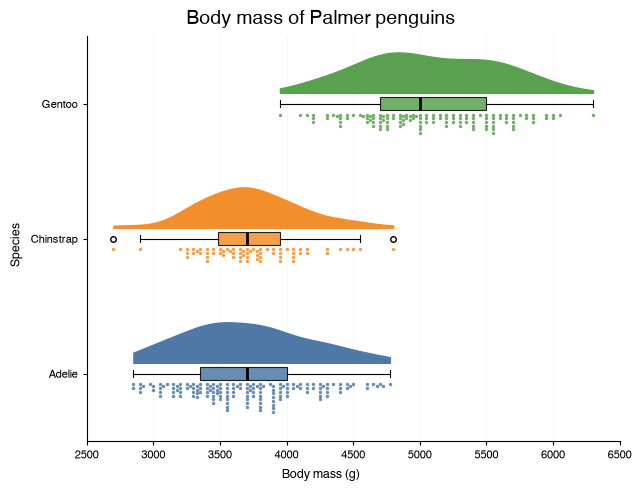

In [12]:
from datachart.constants import ORIENTATION

RaincloudPlot(
    data=chart_data,
    # draw the rainclouds horizontally
    orientation=ORIENTATION.HORIZONTAL,
    title="Body mass of Palmer penguins",
    # the axis labels swap with the orientation
    xlabel="Body mass (g)",
    ylabel="Species",
    figsize=FIG_SIZE.FULL_MEDIUM,
    # and so does the grid
    show_grid=SHOW_GRID.X,
).show()

### Emphasis

A chart usually makes one point, and emphasis makes it visible. `emphasis` takes one role per group, aligned with the group labels in the order they first appear (here Adelie, Chinstrap, Gentoo), and applies to the cloud, the rain and the box together: `"highlight"` bolds the edges, `"background"` mutes the group, `None` leaves it as it is, and a single value applies to every group. The roles are the [EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constants; the [Highlighting](../../styling/highlighting/) guide covers emphasis across chart types and themes. Asking only about Gentoo penguins turns the other two species into context:

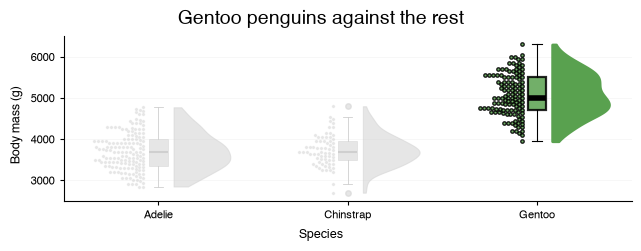

In [13]:
from datachart.constants import EMPHASIS

RaincloudPlot(
    data=chart_data,
    # one role per group label: Adelie, Chinstrap, Gentoo
    emphasis=[EMPHASIS.BACKGROUND, EMPHASIS.BACKGROUND, EMPHASIS.HIGHLIGHT],
    title="Gentoo penguins against the rest",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

`emphasis_rule` picks the groups from the data instead. It is a one-key rule, `{"above": v}` or `{"below": v}` (strict), `{"between": (lo, hi)}` (inclusive), `{"top": n}` or `{"bottom": n}`, read against a summary of each group: the median by default, the line the box already draws, or the `"mean"`, `"min"`, `"max"` or `"sum"` with a `"by"` key. An explicit `emphasis` role wins over the rule. Which species have penguins lighter than 3 kg? Reading the rule against each group's minimum answers it: Adelie and Chinstrap do, Gentoo does not.

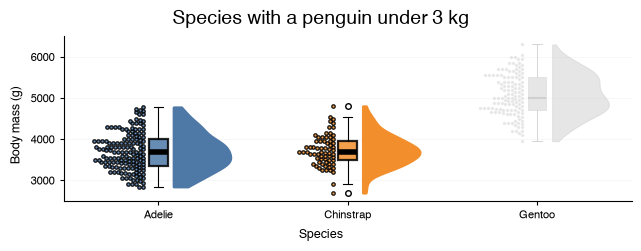

In [14]:
RaincloudPlot(
    data=chart_data,
    # highlight the groups whose lightest penguin is under 3,000 g
    emphasis_rule={"below": 3000, "by": "min"},
    title="Species with a penguin under 3 kg",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Reference lines and bands

Reference lines and bands put the rainclouds in context. `hlines` draws a horizontal line at a value, such as the mean of all penguins, and `vlines` a vertical one; group positions along the category axis start at `0`, as for bars, so a half-integer sits between two groups. `hspans` and `vspans` shade a range instead of marking a value. Each takes a dictionary or a list of them, with the position and a `style`; the keys are listed in [HLineSettingAttrs](../../../references/typings/#datachart.typings.HLineSettingAttrs), [VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs), [HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs) and [VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs). A band of one standard deviation around the overall mean shows that a typical Adelie or Chinstrap penguin falls inside it, while most Gentoo penguins sit above it.

`dlines` completes the trio. Where `vlines` fixes an x and `hlines` a y, a diagonal is fixed by a `slope` and an `intercept`, so it runs through the data space instead of across it; `dlines={}` on its own draws the parity line `y = x`. It spans the axes unless `xmin` and `xmax` clip it to a segment, and takes the same optional `label` and `style`; the keys are listed in [DLineSettingAttrs](../../../references/typings/#datachart.typings.DLineSettingAttrs). The groups sit at `0`, `1`, `2`, so a diagonal asks whether they step up evenly: the line runs from the first group's mean to the last, and a cloud that hangs below it weighs less than an even step would give it.

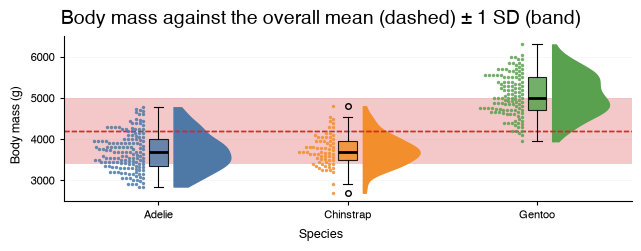

In [15]:
from datachart.constants import LINE_STYLE

masses = [point["value"] for point in chart_data]
mean_mass = sum(masses) / len(masses)
std_mass = (sum((mass - mean_mass) ** 2 for mass in masses) / len(masses)) ** 0.5

RaincloudPlot(
    data=chart_data,
    # shade one standard deviation around the mean of all penguins
    hspans={
        "ymin": mean_mass - std_mass,
        "ymax": mean_mass + std_mass,
        "style": {"plot_hspan_color": "#d62728"},
    },
    # and mark the mean itself
    hlines={
        "y": mean_mass,
        "style": {"plot_hline_color": "#d62728", "plot_hline_style": LINE_STYLE.DASHED},
    },
    title="Body mass against the overall mean (dashed) ± 1 SD (band)",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

In [ ]:
groups = list(dict.fromkeys(point["label"] for point in chart_data))
means = [
    sum(point["value"] for point in chart_data if point["label"] == name)
    / sum(1 for point in chart_data if point["label"] == name)
    for name in groups
]
# an even step from the first group to the last
even_step = (means[-1] - means[0]) / (len(groups) - 1)

RaincloudPlot(
    data=chart_data,
    # the line the means would sit on if the groups stepped up evenly
    dlines={
        "slope": even_step,
        "intercept": means[0],
        "label": "even step between groups",
        "style": {"plot_dline_color": "#1d3557", "plot_dline_style": LINE_STYLE.DASHED},
    },
    title="Body mass against an even step between groups",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Text annotations

Where a reference line marks a value, a note explains it. `texts` places text on the chart, with an optional `target` to draw a connector to a point; the position is in data coordinates by default (group position, value) or in axes fractions with `"coords": "axes"`, which keeps the note in place whatever the axis limits. The [Text Annotations](../../utility/annotations/) guide covers placement, connector looks and styling. The note below points at the heaviest penguin of the dataset, a 6.3 kg Gentoo male, whose rain point sits just left of the Gentoo position `2`.

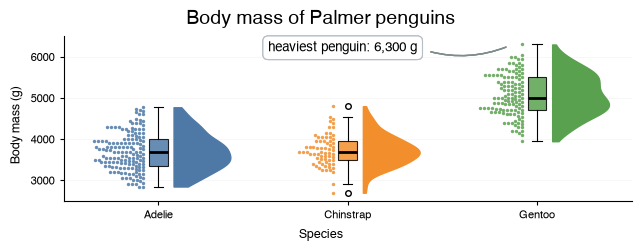

In [16]:
heaviest = max(point["value"] for point in chart_data)

RaincloudPlot(
    data=chart_data,
    # a note pinned to the axes, pointing at the heaviest penguin
    texts={
        "text": f"heaviest penguin: {heaviest:,} g",
        "x": 0.36,
        "y": 0.93,
        "coords": "axes",
        "target": (1.87, heaviest),
    },
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Date labels

Groups are often periods: months, weeks, editions of a survey. A `label` that is a real temporal object (`datetime`, `date`, `numpy.datetime64` or a pandas `Timestamp`) keeps its categorical position but prints through `xticks_format`, a [DATE_FORMAT](../../../references/constants/#datachart.constants.DATE_FORMAT) member or any `strftime` pattern. `daily_temperatures`, defined in a hidden cell, holds twenty illustrative daily mean temperatures per month, drawn around the 1991-2020 monthly normals of Ljubljana and labeled by the first day of each month. The rainclouds show the seasonal cycle and that winter days vary more than summer days.

In [17]:
from datetime import date

import numpy as np

# mean monthly temperature in °C (1991-2020 normals of Ljubljana) and the day-to-day spread
MONTHLY_MEAN = [0.8, 2.4, 6.8, 11.5, 16.2, 20.1, 22.0, 21.4, 16.6, 11.5, 5.9, 1.3]
MONTHLY_SPREAD = [4.0, 4.0, 3.5, 3.0, 2.5, 2.5, 2.5, 2.5, 3.0, 3.5, 3.5, 4.0]

rng = np.random.RandomState(11)
daily_temperatures = [
    {"label": date(2024, month, 1), "value": round(float(temperature), 1)}
    for month, mean, spread in zip(range(1, 13), MONTHLY_MEAN, MONTHLY_SPREAD)
    for temperature in rng.normal(mean, spread, 20)
]

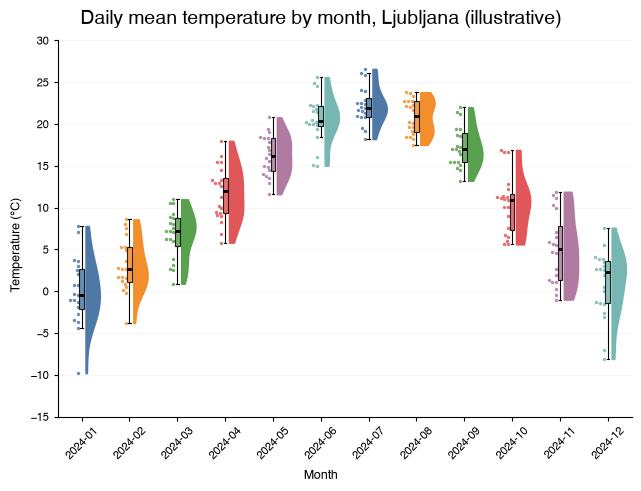

In [18]:
from datachart.constants import DATE_FORMAT

RaincloudPlot(
    data=daily_temperatures,
    title="Daily mean temperature by month, Ljubljana (illustrative)",
    xlabel="Month",
    ylabel="Temperature (°C)",
    # print the date labels as year and month
    xticks_format=DATE_FORMAT.YEAR_MONTH,
    xtickrotate=45,
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    show_outliers=False,
).show()

### Legend

The category axis already names the groups, so a legend is mostly for reference marks or for charts whose tick labels are hidden. `show_legend` lists the groups; `legend` says where and how, with a `title`, a `location` from [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION), the number of columns `ncols`, and the `alignment` of the entries from [LEGEND_ALIGN](../../../references/constants/#datachart.constants.LEGEND_ALIGN); a field left out falls back to the theme ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)). The Adelie and Chinstrap rainclouds fill the lower half of the axes, so a titled legend goes above the plot, in one row.

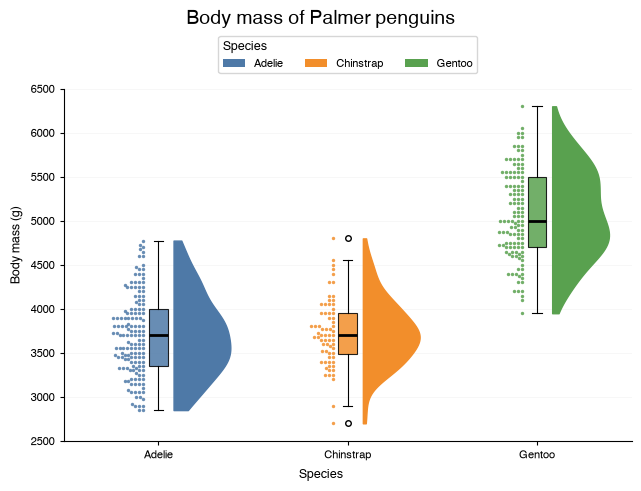

In [19]:
from datachart.constants import LEGEND_LOCATION

RaincloudPlot(
    data=chart_data,
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
    # a titled, one-row legend above the axes
    legend={"title": "Species", "location": LEGEND_LOCATION.OUTSIDE_TOP, "ncols": 3},
).show()

## Multiple Raincloud Plots

Three parts per group leave no room to overlay a second dataset at the same positions, so a list of lists in `data` draws each inner list in its own subplot. `subtitle` titles the subplots; `title`, `xlabel` and `ylabel` stay global; `max_cols` limits the subplots per row. `sharey=True` puts the subplots on one value axis, so a raincloud in one can be read against a raincloud in the next, and `sharex=True` does the same for the category axis. A per-chart attribute (`style`, `emphasis`, `hlines`, …) can be a list aligned with `data`.

Splitting the penguins by sex answers the question the [bandwidth](#cloud-bandwidth) example raised: each species' two humps are its females and its males. `body_mass_by_sex` holds the 165 female and the 168 male penguins, one list per sex (the 9 penguins without a recorded sex are left out).

In [20]:
SEXES = ["Female", "Male"]

# one list of data points per sex
body_mass_by_sex = [
    [
        {"label": penguin["species"], "value": mass}
        for penguin in PENGUINS
        if penguin["sex"] == sex
        for mass in penguin["body_mass"]
    ]
    for sex in SEXES
]

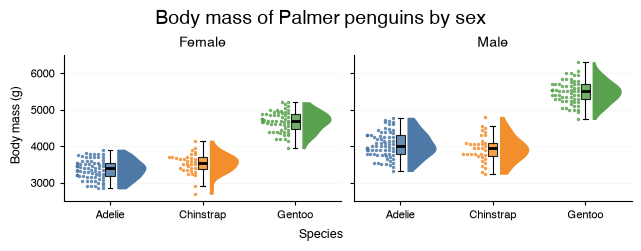

In [21]:
RaincloudPlot(
    # one chart per sex
    data=body_mass_by_sex,
    # one subplot title per chart
    subtitle=SEXES,
    title="Body mass of Palmer penguins by sex",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_outliers=False,
    # the same mass axis for both charts, with room for the heaviest males
    sharey=True,
    ymin=2500,
    ymax=6500,
).show()

Each sex now has a single-humped cloud, and a shared axis shows that a male of one species is heavier than a female of the same species. A single value of `emphasis` applies to every group of every chart, and a list of lists gives each chart its own roles; the example keeps the Gentoo groups in front in both subplots, and stacks the subplots in a column with `max_cols=1`:

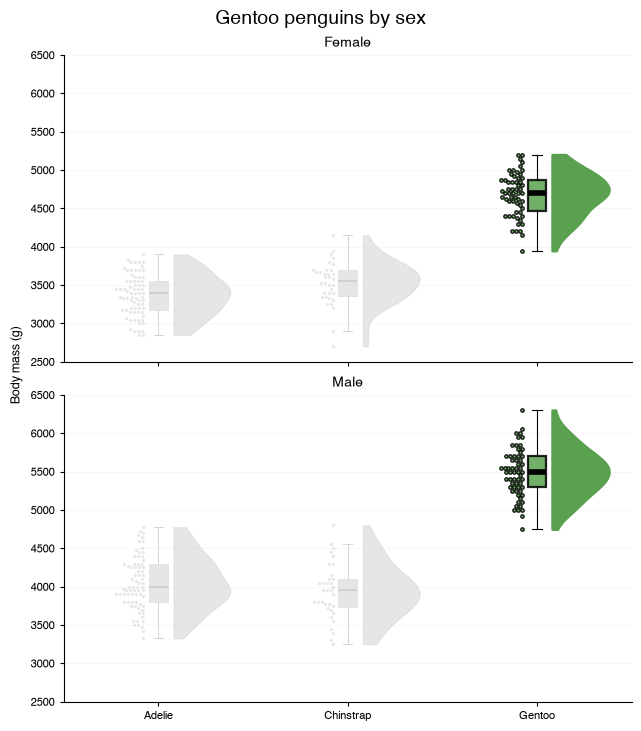

In [22]:
RaincloudPlot(
    data=body_mass_by_sex,
    subtitle=SEXES,
    # the same roles in both charts: Adelie, Chinstrap, Gentoo
    emphasis=[
        [EMPHASIS.BACKGROUND, EMPHASIS.BACKGROUND, EMPHASIS.HIGHLIGHT],
        [EMPHASIS.BACKGROUND, EMPHASIS.BACKGROUND, EMPHASIS.HIGHLIGHT],
    ],
    title="Gentoo penguins by sex",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_TALL,
    show_grid=SHOW_GRID.Y,
    show_outliers=False,
    # one chart per row, on one mass axis
    max_cols=1,
    sharex=True,
    sharey=True,
    ymin=2500,
    ymax=6500,
).show()

### Composing with Panel and Grid

[Panel](../../utility/panel/) overlays figures on shared axes, one raincloud dataset per panel. The groups keep their positions (`1`, `2`, `3`, …), so a chart drawn on the same numeric positions lines up with them. A [LineChart](../../../references/charts/linechart/#datachart.charts.LineChart) of the mean body mass per species traces the step from the small species to the large one, and shows where the mean sits against the median line of each box.

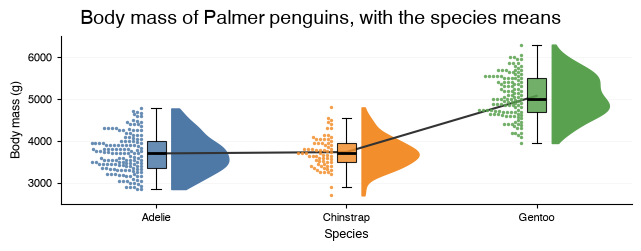

In [23]:
from datachart.charts import LineChart
from datachart.utils import Panel

mean_by_species = [
    {
        # group positions start at 0
        "x": position,
        "y": sum(p["value"] for p in chart_data if p["label"] == species)
        / sum(1 for p in chart_data if p["label"] == species),
    }
    for position, species in enumerate(SPECIES)
]

Panel(
    [
        RaincloudPlot(data=chart_data, show_outliers=False),
        # the means, one per group position
        LineChart(data=mean_by_species, style={"plot_line_color": "#333333"}),
    ],
    title="Body mass of Palmer penguins, with the species means",
    xlabel="Species",
    ylabel_left="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

[Grid](../../utility/grid/) arranges figures side by side, each in its own cell. Is the size gap between the species a matter of weight alone? A raincloud of the flipper lengths next to the body mass one says no: Gentoo penguins have longer flippers too, and the Chinstrap flippers sit between the other two species, a difference the body mass hides.

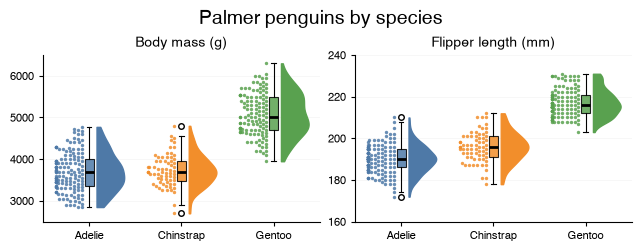

In [24]:
from datachart.utils import Grid

Grid(
    [
        RaincloudPlot(data=chart_data, title="Body mass (g)", show_grid=SHOW_GRID.Y),
        RaincloudPlot(data=flipper_data, title="Flipper length (mm)", show_grid=SHOW_GRID.Y),
    ],
    title="Palmer penguins by species",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

## Additional Features

### Logarithmic scale

Some measurements are strongly right-skewed: most values are small and a few are many times larger, so on a linear axis the bulk of each group is squeezed against the bottom. `scaley` takes a [SCALE](../../../references/constants/#datachart.constants.SCALE) member, and on `SCALE.LOG` the cloud, the rain and the box all follow the scaled axis. Penguin masses are not skewed, so this example switches dataset: `load_times`, defined in a hidden cell, holds 150 illustrative page load times (in ms) for each of three page types, drawn from log-normal distributions. On the log scale the three clouds become symmetric and readable, and the tails stay in view.

In [25]:
import numpy as np

# illustrative page load times in ms: (page type, median, log-scale spread)
PAGES = [("Static page", 180, 0.5), ("Search", 650, 0.7), ("Checkout", 1400, 0.8)]

rng = np.random.RandomState(42)
load_times = [
    {"label": page, "value": round(float(ms))}
    for page, median, spread in PAGES
    for ms in rng.lognormal(np.log(median), spread, 150)
]

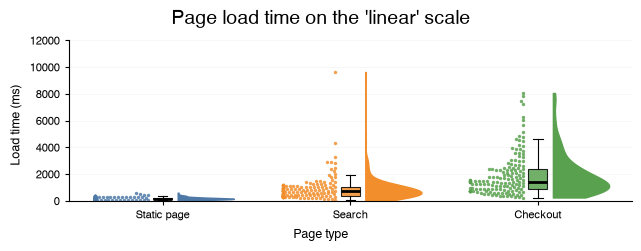

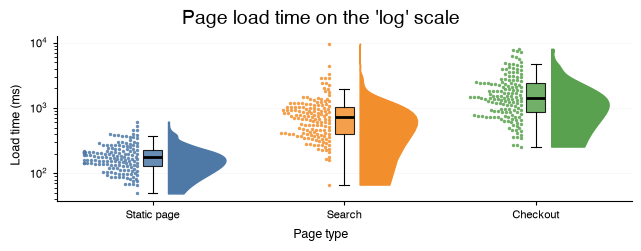

In [26]:
from datachart.constants import SCALE

for scale in [SCALE.LINEAR, SCALE.LOG]:
    RaincloudPlot(
        data=load_times,
        title=f"Page load time on the '{scale}' scale",
        xlabel="Page type",
        ylabel="Load time (ms)",
        figsize=FIG_SIZE.FULL_SHORT,
        show_grid=SHOW_GRID.Y,
        show_outliers=False,
        # the scale of the value axis
        scaley=scale,
    ).show()

### Custom data keys

Data that comes from a file or an API rarely uses the `label` and `value` keys, and renaming every record just to plot it is a chore. Instead, tell `RaincloudPlot` which keys to read with the `label` and `value` arguments. `flipper_records` stores the flipper lengths the way a CSV export would, one record per penguin with a `species` and a `flipper_mm` key:

In [27]:
flipper_records = [
    {"species": penguin["species"], "sex": penguin["sex"], "flipper_mm": length}
    for penguin in PENGUINS
    for length in penguin["flipper_length"]
]
flipper_records[:2]

[{'species': 'Adelie', 'sex': 'Female', 'flipper_mm': 186},
 {'species': 'Adelie', 'sex': 'Female', 'flipper_mm': 195}]

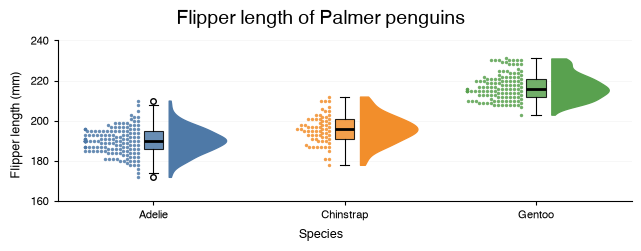

In [28]:
RaincloudPlot(
    data=flipper_records,
    # the keys holding the label and the value
    label="species",
    value="flipper_mm",
    title="Flipper length of Palmer penguins",
    xlabel="Species",
    ylabel="Flipper length (mm)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

## Real-World Examples

The examples below put the features above to work on realistic data, each one answering a question. The data lives in hidden cells; each example says what its data is and where it comes from.

### Example 1: Does Conflict Slow People Down? (Strip Rain, a Log Scale, Median Labels, and a Baseline)

The raincloud plot was made for experimental results like these. `stroop_trials` holds illustrative reaction times (in ms) from a Stroop task, 300 trials per condition: the colour word matches its ink (*congruent*), is a neutral string (*neutral*), or names another colour (*incongruent*). The times are drawn from an ex-Gaussian distribution, the usual model of reaction times: a normal bulk plus an exponential tail of slow responses. With 300 trials per group the rain is drawn as a strip, the skewed times go on a log axis, the median labels give each condition's typical time, and a dashed line at the congruent median is the baseline the other two conditions are read against. The incongruent median sits about 150 ms above it, and its tail of slow responses is the longest.

In [29]:
# illustrative Stroop reaction times in ms: (condition, normal mean, normal SD, tail mean)
CONDITIONS = [("Congruent", 560, 60, 90), ("Neutral", 590, 65, 110), ("Incongruent", 660, 75, 160)]

rng = np.random.RandomState(42)
stroop_trials = [
    {"label": condition, "value": round(float(rt))}
    for condition, mu, sigma, tau in CONDITIONS
    for rt in rng.normal(mu, sigma, 300) + rng.exponential(tau, 300)
]
CONGRUENT_MEDIAN = float(np.median([p["value"] for p in stroop_trials if p["label"] == "Congruent"]))

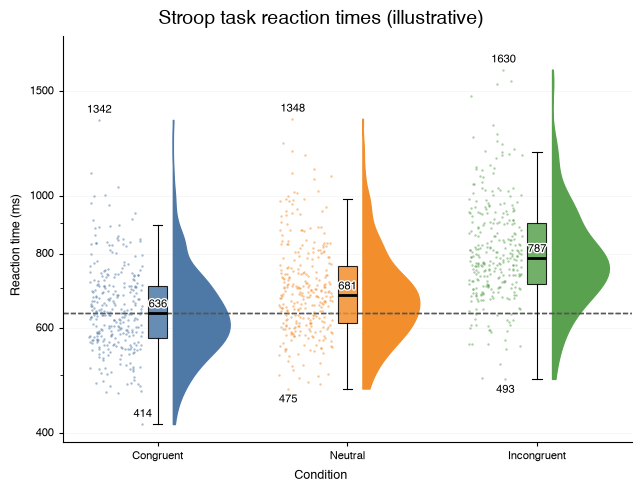

In [30]:
RaincloudPlot(
    data=stroop_trials,
    style={"plot_swarm_size": 3, "plot_swarm_alpha": 0.5, "plot_value_fontsize": 8},
    # 300 trials per condition: scatter instead of packing
    mode=SWARM_MODE.STRIP,
    # reaction times are right-skewed
    scaley=SCALE.LOG,
    yticks=[400, 600, 800, 1000, 1500],
    yticks_format=VALUE_FORMAT.INTEGER,
    # print the median, min and max
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
    show_outliers=False,
    # the congruent median as the baseline
    hlines={
        "y": CONGRUENT_MEDIAN,
        "style": {"plot_hline_color": "#555555", "plot_hline_style": LINE_STYLE.DASHED},
    },
    title="Stroop task reaction times (illustrative)",
    xlabel="Condition",
    ylabel="Reaction time (ms)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
).show()

### Example 2: Did the Course Lift the Scores? (Subplots, a Pass Band, Custom Keys, and a Rule)

`course_scores` holds illustrative test scores (0 to 100) of two sections of the same statistics course, 60 students each, before and after the course. The records use the keys a gradebook export would, `test` and `score`, so the `label` and `value` arguments read them directly. The pass mark is 50: a band shades the failing range, and `emphasis_rule` highlights the tests whose median passes. The shared axis shows that both sections improved, and the rain shows what the medians hide: the evening section still leaves a group of students below the pass mark.

In [31]:
# illustrative test scores (0-100): (section, test, mean, SD)
SCORES = [
    ("Morning", "Before", 42, 12), ("Morning", "After", 71, 10),
    ("Evening", "Before", 40, 13), ("Evening", "After", 63, 16),
]
SECTIONS = ["Morning", "Evening"]

rng = np.random.RandomState(42)
course_scores = [
    [
        {"test": test, "score": int(np.clip(round(s), 0, 100))}
        for sec, test, mean, sd in SCORES
        if sec == section
        for s in rng.normal(mean, sd, 60)
    ]
    for section in SECTIONS
]
PASS_MARK = 50

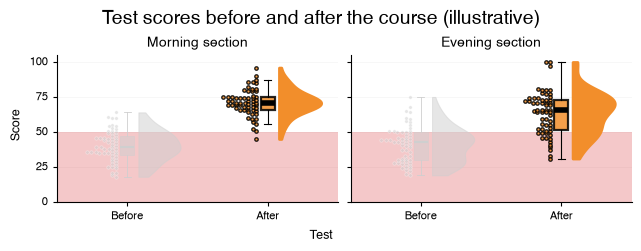

In [32]:
RaincloudPlot(
    data=course_scores,
    # the gradebook's key names
    label="test",
    value="score",
    subtitle=[f"{section} section" for section in SECTIONS],
    # shade the failing range in both charts
    hspans={"ymin": 0, "ymax": PASS_MARK, "label": "fail", "style": {"plot_hspan_color": "#d62728"}},
    # the tests whose median passes
    emphasis_rule={"above": PASS_MARK},
    show_outliers=False,
    title="Test scores before and after the course (illustrative)",
    xlabel="Test",
    ylabel="Score",
    # headroom for the perfect scores
    ymin=0,
    ymax=105,
    yticks=[0, 25, 50, 75, 100],
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    sharey=True,
).show()

### Example 3: Which Courier Keeps the 48-Hour Promise? (Horizontal Rainclouds, a Promise Line, a Note, and a Grid)

An online shop promises delivery within 48 hours and uses four couriers. `delivery_hours` holds illustrative delivery times (in hours) of 120 parcels per courier, and `late_share` the share of each courier's parcels that missed the promise. Horizontal rainclouds give the hours a left-to-right axis, a line marks the promise, and a note points at the courier with the longest tail. The median alone would rank the couriers wrongly: Swift has the fastest typical delivery but the most late parcels. [Grid](../../utility/grid/) sets a bar chart of the late share beside the rainclouds, in the same order, so the two views of each courier sit on one row.

In [33]:
# illustrative delivery times in hours: (courier, typical hours, spread, share of delayed parcels, delay hours)
COURIERS = [("Parcelo", 30, 6, 0.04, 20), ("Northway", 36, 4, 0.02, 15), ("Swift", 24, 5, 0.22, 40), ("Boxline", 34, 5, 0.06, 20)]
PROMISE = 48

rng = np.random.RandomState(42)
delivery_hours = []
late_share = []
for courier, typical, spread, delayed, delay in COURIERS:
    hours = rng.normal(typical, spread, 120) + (rng.rand(120) < delayed) * rng.exponential(delay, 120)
    hours = np.clip(hours, 4, None).round(1)
    delivery_hours += [{"label": courier, "value": float(h)} for h in hours]
    late_share.append({"label": courier, "y": float((hours > PROMISE).mean())})

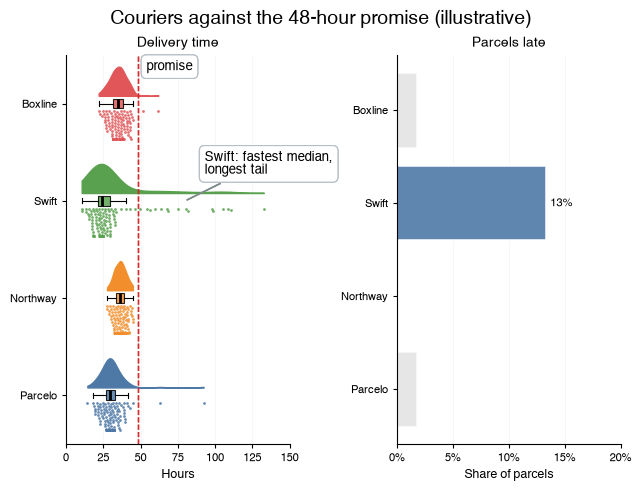

In [34]:
from datachart.charts import BarChart

rainclouds = RaincloudPlot(
    data=delivery_hours,
    orientation=ORIENTATION.HORIZONTAL,
    style={"plot_swarm_size": 4},
    show_outliers=False,
    # the delivery promise
    vlines={
        "x": PROMISE,
        "style": {"plot_vline_color": "#d62728", "plot_vline_style": LINE_STYLE.DASHED},
    },
    texts=[
        # name the promise line
        {"text": "promise", "x": 0.36, "y": 0.97, "coords": "axes"},
        # point at Swift's long tail
        {
            "text": "Swift: fastest median,\nlongest tail",
            "x": 0.62,
            "y": 0.72,
            "coords": "axes",
            "target": (80, 2),
        },
    ],
    title="Delivery time",
    xlabel="Hours",
    xmin=0,
    show_grid=SHOW_GRID.X,
)

late = BarChart(
    data=late_share,
    orientation=ORIENTATION.HORIZONTAL,
    # Swift, the courier the note is about
    emphasis_rule={"top": 1},
    show_values=True,
    value_format=VALUE_FORMAT.PERCENT_INT,
    title="Parcels late",
    xlabel="Share of parcels",
    xmin=0,
    xmax=0.2,
    xticks_format=VALUE_FORMAT.PERCENT_INT,
    show_grid=SHOW_GRID.X,
)

Grid(
    [[rainclouds, late]],
    title="Couriers against the 48-hour promise (illustrative)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()